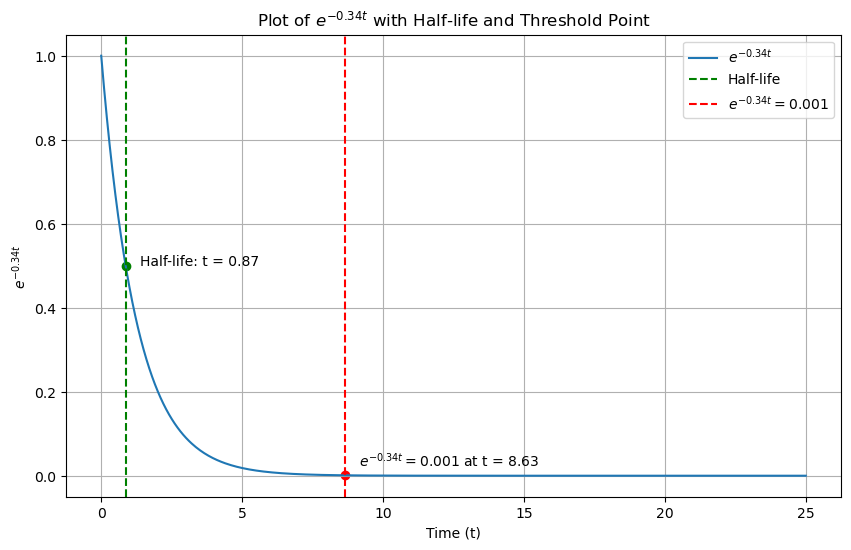

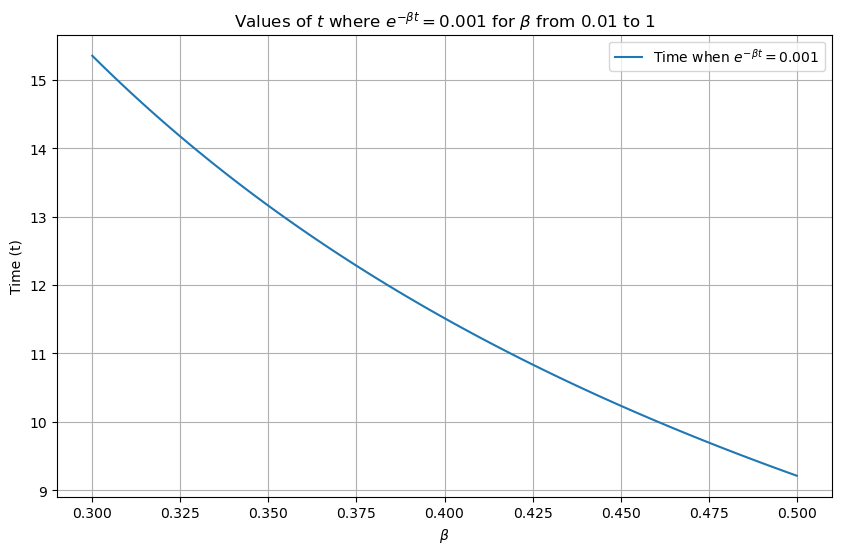

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# First Plot: e^{-βt} for β = 0.34
beta = 0.8
t = np.linspace(0, 25, 500)
y = np.exp(-beta * t)

# Calculate half-life point
t_half = np.log(2) / beta
y_half = np.exp(-beta * t_half)

# Calculate point where e^{-βt} < 0.001
t_threshold = np.log(1/0.001) / beta
y_threshold = np.exp(-beta * t_threshold)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(t, y, label=r'$e^{-0.34 t}$')
plt.axvline(t_half, color='green', linestyle='--', label='Half-life')
plt.axvline(t_threshold, color='red', linestyle='--', label=r'$e^{-0.34 t} = 0.001$')
plt.scatter([t_half], [y_half], color='green')
plt.scatter([t_threshold], [y_threshold], color='red')

# Annotations
plt.text(t_half + 0.5, y_half, f'Half-life: t = {t_half:.2f}')
plt.text(t_threshold + 0.5, y_threshold + 0.02, f'$e^{{-0.34 t}} = 0.001$ at t = {t_threshold:.2f}')

plt.title(r'Plot of $e^{-0.34 t}$ with Half-life and Threshold Point')
plt.xlabel('Time (t)')
plt.ylabel(r'$e^{-0.34 t}$')
plt.legend()
plt.grid(True)
plt.show()

# Second Plot: t vs β where e^{-βt} < 0.001
beta_values = np.linspace(0.3, 0.5, 100)
t_values = np.log(1/0.01) / beta_values  # Solve for t where e^{-βt} = 0.001

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(beta_values, t_values, label=r'Time when $e^{-\beta t} = 0.001$')
plt.title(r'Values of $t$ where $e^{-\beta t} = 0.001$ for $\beta$ from 0.01 to 1')
plt.xlabel(r'$\beta$')
plt.ylabel('Time (t)')
plt.legend()
plt.grid(True)
plt.show()


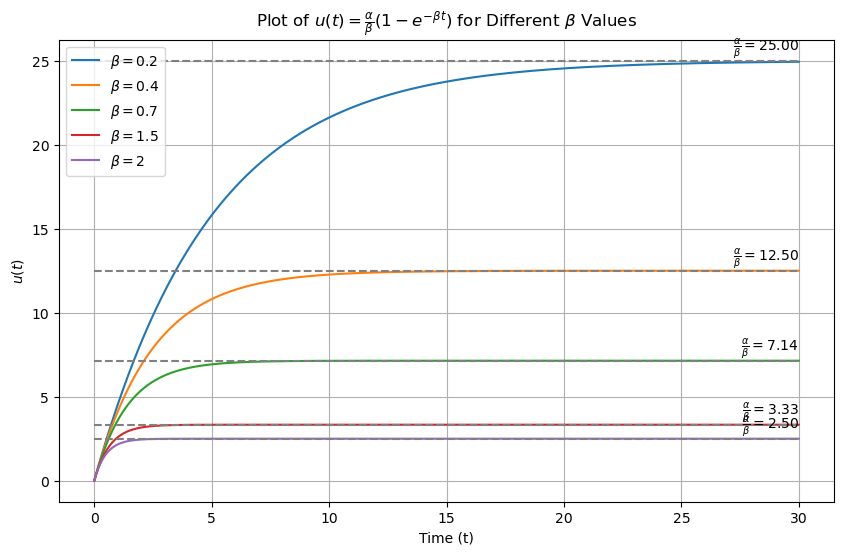

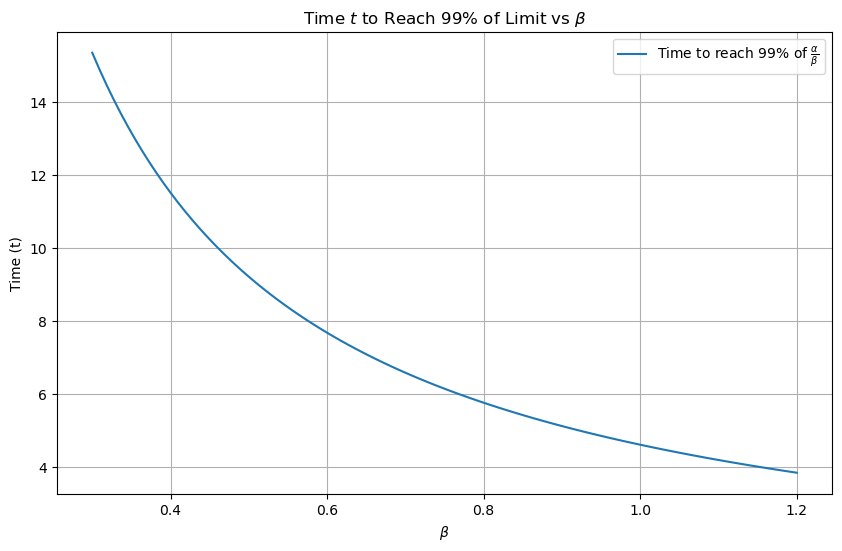

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Define alpha
alpha = 5

# First Plot: u(t) for different beta values
beta_values = [0.2, 0.4, 0.7, 1.5, 2]
t = np.linspace(0, 30, 500)

plt.figure(figsize=(10, 6))

for beta in beta_values:
    u = (alpha / beta) * (1 - np.exp(-beta * t))
    limit = alpha / beta
    plt.plot(t, u, label=r'$\beta = {}$'.format(beta))
    plt.hlines(limit, t[0], t[-1], colors='gray', linestyles='dashed')
    plt.text(t[-1], limit + 0.02, r'$\frac{{\alpha}}{{\beta}} = {:.2f}$'.format(limit), 
             verticalalignment='bottom', horizontalalignment='right')

plt.title(r'Plot of $u(t) = \frac{{\alpha}}{{\beta}}(1 - e^{-\beta t})$ for Different $\beta$ Values')
plt.xlabel('Time (t)')
plt.ylabel(r'$u(t)$')
plt.legend()
plt.grid(True)
plt.show()

# Second Plot: Time to reach 99% of the limit vs beta
beta_values = np.linspace(0.3, 1.2, 100)
threshold = 0.99  # 99% of the limit
t_values = -(1 / beta_values) * np.log(1 - threshold)

plt.figure(figsize=(10, 6))
plt.plot(beta_values, t_values, label=r'Time to reach 99% of $\frac{{\alpha}}{{\beta}}$')
plt.title(r'Time $t$ to Reach 99% of Limit vs $\beta$')
plt.xlabel(r'$\beta$')
plt.ylabel('Time (t)')
plt.legend()
plt.grid(True)
plt.show()


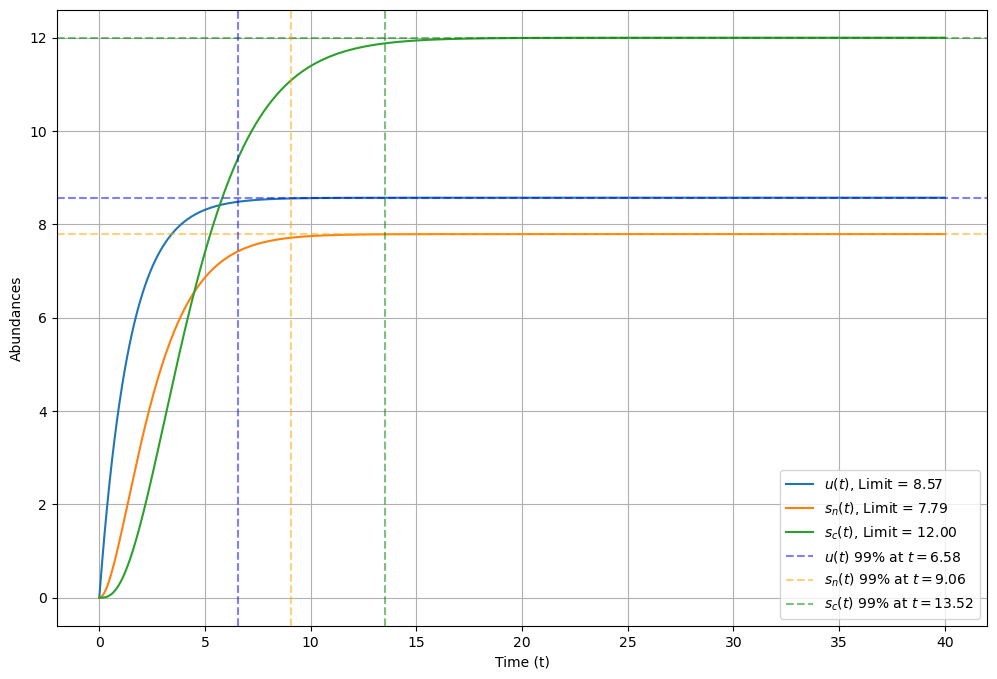

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# 8.7, 3.2, 1.95, 1.3]
# [6,0.63,0.58,0.6]
# Parameters
alpha = 6
beta = 0.7
nu = 0.77
gamma = 0.5

# Time array for plotting
t = np.linspace(0, 40, 1000)

# Functions
def u(t):
    return (alpha / beta) * (1 - np.exp(-beta * t))

def s_n(t):
    return (alpha / nu) * (1 - np.exp(-nu * t)) + (alpha / (nu - beta)) * (np.exp(-nu * t) - np.exp(-beta * t))

def s_c(t):
    term1 = ((alpha / beta) * (1 - np.exp(-beta * t))) / ((nu - beta) * (gamma - beta))
    term2 = ((alpha / nu) * (1 - np.exp(-nu * t))) / ((gamma - nu) * (nu - beta))
    term3 = ((alpha / gamma) * (1 - np.exp(-gamma * t))) / ((gamma - nu) * (gamma - beta))
    return nu * beta * (term1 - term2 + term3)

# Limit values
limit_u = alpha / beta
limit_s_n = alpha / nu
limit_s_c = alpha / gamma

# Thresholds (99% of the Limits)
threshold_u = 0.99 * limit_u
threshold_s_n = 0.99 * limit_s_n
threshold_s_c = 0.99 * limit_s_c

# Functions to find roots (difference between function and 99% limit)
def u_diff(t):
    return u(t) - threshold_u

def s_n_diff(t):
    return s_n(t) - threshold_s_n

def s_c_diff(t):
    return s_c(t) - threshold_s_c

# Finding the times when functions reach 99% of their limits
# We'll search for roots in reasonable intervals
t_u_99 = brentq(u_diff, 0, 50)    # Adjust the interval if necessary
t_s_n_99 = brentq(s_n_diff, 0, 50)  # Adjust the interval if necessary
t_s_c_99 = brentq(s_c_diff, 0, 50)  # Adjust the interval if necessary

# Plot u(t), s_n(t), and s_c(t)
plt.figure(figsize=(12, 8))
plt.plot(t, u(t), label=rf'$u(t)$, Limit = {limit_u:.2f}')
plt.plot(t, s_n(t), label=rf'$s_n(t)$, Limit = {limit_s_n:.2f}')
plt.plot(t, s_c(t), label=rf'$s_c(t)$, Limit = {limit_s_c:.2f}')

# Add horizontal lines for limits
plt.axhline(limit_u, color='blue', linestyle='--', alpha=0.5)
plt.axhline(limit_s_n, color='orange', linestyle='--', alpha=0.5)
plt.axhline(limit_s_c, color='green', linestyle='--', alpha=0.5)

# Add vertical lines at times when functions reach 99% of their limits
plt.axvline(t_u_99, color='blue', linestyle='--', alpha=0.5, label=rf'$u(t)$ 99% at $t = {t_u_99:.2f}$')
plt.axvline(t_s_n_99, color='orange', linestyle='--', alpha=0.5, label=rf'$s_n(t)$ 99% at $t = {t_s_n_99:.2f}$')
plt.axvline(t_s_c_99, color='green', linestyle='--', alpha=0.5, label=rf'$s_c(t)$ 99% at $t = {t_s_c_99:.2f}$')

plt.title('')
plt.xlabel('Time (t)')
plt.ylabel('Abundances')
plt.legend()
plt.grid(True)
plt.show()


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# Parameters
# alpha = 6.7
# beta = 2.2
# nu = 1.95
# gamma = 1.3

# [6,0.55,0.5,0.4]

def plot_1(alpha,beta,nu,gamma):


    # Time array for activation phase
    # t_activation = np.linspace(0, 10, 1000)

    # Activation phase functions
    def u_activation(t):
        return (alpha / beta) * (1 - np.exp(-beta * t))

    def s_n_activation(t):
        return (alpha / nu) * (1 - np.exp(-nu * t)) + (alpha / (nu - beta)) * (np.exp(-nu * t) - np.exp(-beta * t))

    def s_c_activation(t):
        term1 = ((alpha / beta) * (1 - np.exp(-beta * t))) / ((nu - beta) * (gamma - beta))
        term2 = ((alpha / nu) * (1 - np.exp(-nu * t))) / ((gamma - nu) * (nu - beta))
        term3 = ((alpha / gamma) * (1 - np.exp(-gamma * t))) / ((gamma - nu) * (gamma - beta))
        return nu * beta * (term1 - term2 + term3)

    # Limit values for activation phase
    limit_u = alpha / beta
    limit_s_n = alpha / nu
    limit_s_c = alpha / gamma

    # Thresholds (97% of the Limits)
    threshold_u = 0.99 * limit_u
    threshold_s_n = 0.99 * limit_s_n
    threshold_s_c = 0.99 * limit_s_c

    # Functions to find roots (difference between function and 99% limit)
    def u_diff(t):
        return u_activation(t) - threshold_u

    def s_n_diff(t):
        return s_n_activation(t) - threshold_s_n

    def s_c_diff(t):
        return s_c_activation(t) - threshold_s_c

    # Finding the times when functions reach 99% of their limits
    t_u_99 = brentq(u_diff, 0, 50)
    t_s_n_99 = brentq(s_n_diff, 0, 50)
    t_s_c_99 = brentq(s_c_diff, 0, 50)

    # Determine t_s
    t_s = max(t_u_99, t_s_n_99, t_s_c_99)
    print(f"Initial time t_s = {t_s:.2f}")

    # Calculate initial counts at t_s
    u_t_s = u_activation(t_s)
    s_n_t_s = s_n_activation(t_s)
    s_c_t_s = s_c_activation(t_s)
    print(f"Initial counts at t_s: u({t_s:.2f}) = {u_t_s:.2f}, s_n({t_s:.2f}) = {s_n_t_s:.2f}, s_c({t_s:.2f}) = {s_c_t_s:.2f}")

    # Time array for repression phase
    t_repression = np.linspace(t_s, t_s + 30, 1000)

    # Repression phase functions (alpha = 0)
    def u_repression(t):
        return u_t_s * np.exp(-beta * (t - t_s))

    def s_n_repression(t):
        term1 = s_n_t_s * np.exp(-nu * (t - t_s))
        term2 = (beta * u_t_s) / (nu - beta) * (np.exp(-nu * (t - t_s)) - np.exp(-beta * (t - t_s)))
        return term1 - term2

    def s_c_repression(t):
        term1 = (u_t_s * np.exp(-beta * (t - t_s))) / ((nu - beta) * (gamma - beta))
        term2 = (u_t_s * np.exp(-nu * (t - t_s))) / ((gamma - nu) * (nu - beta))
        term3 = (u_t_s * np.exp(-gamma * (t - t_s))) / ((gamma - nu) * (gamma - beta))
        part1 = nu * beta * (term1 - term2 + term3)
        part2 = (nu / (gamma - nu)) * (np.exp(-nu * (t - t_s)) - np.exp(-gamma * (t - t_s))) * s_n_t_s
        part3 = np.exp(-gamma * (t - t_s)) * s_c_t_s
        return part1 + part2 + part3

    # Functions to find when counts decrease to 1% of initial values
    def u_repression_diff(t):
        return u_repression(t) - 0.5 * u_t_s

    def s_n_repression_diff(t):
        return s_n_repression(t) - 0.1 * s_n_t_s

    def s_c_repression_diff(t):
        return s_c_repression(t) - 0.1 * s_c_t_s

    # Finding times when counts decrease to 1% of initial values
    t_u_1 = t_s - np.log(0.01) / beta  # Analytical solution for u(t)
    t_s_n_1 = brentq(s_n_repression_diff, t_s, t_s + 100)
    t_s_c_1 = brentq(s_c_repression_diff, t_s, t_s + 100)
    print(f"Times when counts decrease to 1% of initial values:")
    print(f"u(t): t = {t_u_1:.2f}")
    print(f"s_n(t): t = {t_s_n_1:.2f}")
    print(f"s_c(t): t = {t_s_c_1:.2f}")

    # Plotting the repression phase
    plt.figure(figsize=(12, 8))
    plt.plot(t_repression, u_repression(t_repression), label=r'$u(t)$')
    plt.plot(t_repression, s_n_repression(t_repression), label=r'$s_n(t)$')
    plt.plot(t_repression, s_c_repression(t_repression), label=r'$s_c(t)$')

    # Add horizontal lines at 1% of initial values
    plt.axhline(0.01 * u_t_s, color='blue', linestyle='--', alpha=0.5)
    plt.axhline(0.01 * s_n_t_s, color='orange', linestyle='--', alpha=0.5)
    plt.axhline(0.01 * s_c_t_s, color='green', linestyle='--', alpha=0.5)

    # Add vertical lines at times when counts decrease to 1% of initial values
    plt.axvline(t_u_1, color='blue', linestyle='--', alpha=0.5, label=rf'$u(t)$ reaches 1% at $t = {t_u_1:.2f}$')
    plt.axvline(t_s_n_1, color='orange', linestyle='--', alpha=0.5, label=rf'$s_n(t)$ reaches 1% at $t = {t_s_n_1:.2f}$')
    plt.axvline(t_s_c_1, color='green', linestyle='--', alpha=0.5, label=rf'$s_c(t)$ reaches 1% at $t = {t_s_c_1:.2f}$')

    plt.title('Repression Phase: $u(t)$, $s_n(t)$, and $s_c(t)$ Decreasing Over Time')
    plt.xlabel('Time (t)')
    plt.ylabel('Counts')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Optional: Combine activation and repression phases into one plot
    # Time array for combined phases
    t_combined = np.linspace(0, t_s + 10, 2000)
    # Evaluate the functions over the combined time array
    u_combined = np.piecewise(t_combined, [t_combined <= t_s, t_combined > t_s],
                            [u_activation, u_repression])
    s_n_combined = np.piecewise(t_combined, [t_combined <= t_s, t_combined > t_s],
                                [s_n_activation, s_n_repression])
    s_c_combined = np.piecewise(t_combined, [t_combined <= t_s, t_combined > t_s],
                                [s_c_activation, s_c_repression])

    # Plotting the combined phases
    plt.figure(figsize=(12, 8))
    plt.plot(t_combined, u_combined, label=r'$u(t)$')
    plt.plot(t_combined, s_n_combined, label=r'$s_n(t)$')
    plt.plot(t_combined, s_c_combined, label=r'$s_c(t)$')

    plt.axvline(t_s, color='red', linestyle='--', alpha=0.7, label=rf'Switch at $t = {t_s:.2f}$')

    plt.title('Activation and Repression Phases Combined')
    plt.xlabel('Time (t)')
    plt.ylabel('Counts')
    plt.legend()
    plt.grid(True)
    plt.show()


Initial time t_s = 13.36
Initial counts at t_s: u(13.36) = 11.98, s_n(13.36) = 1.20, s_c(13.36) = 11.65
Times when counts decrease to 1% of initial values:
u(t): t = 22.57
s_n(t): t = 18.17
s_c(t): t = 21.29


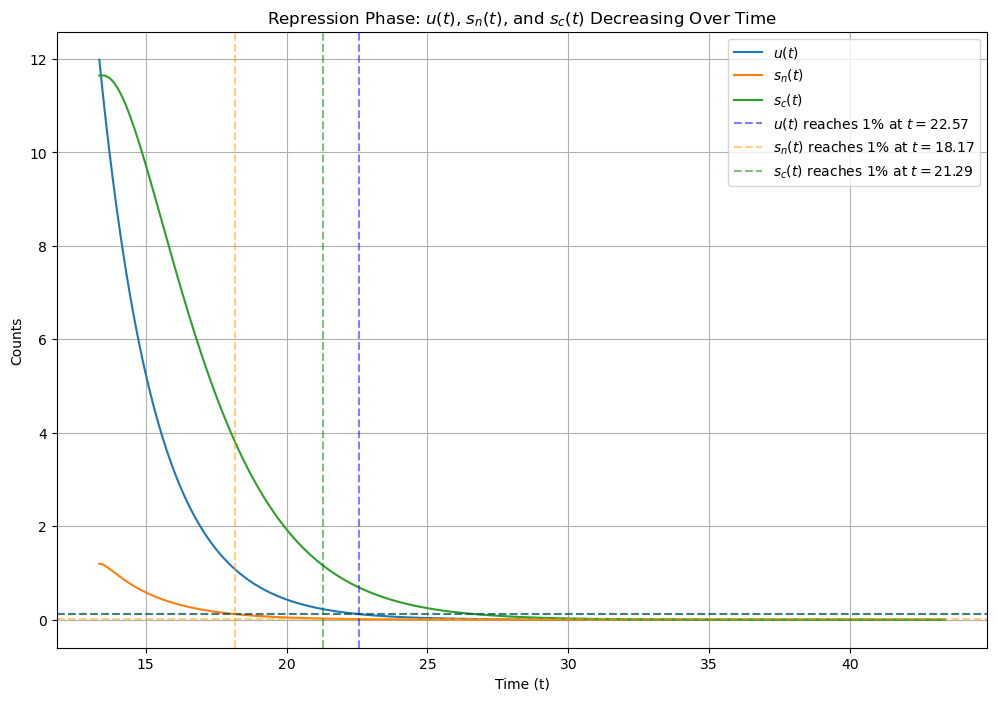

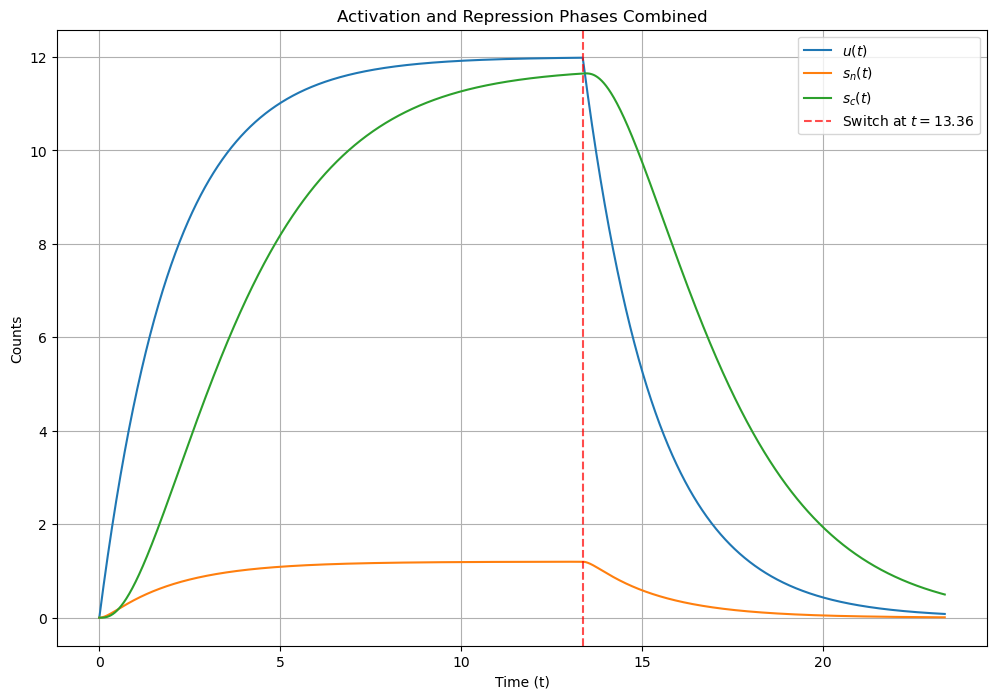

In [17]:
alpha = 6
beta = 0.5
nu = 5
gamma = 0.51
plot_1(alpha,beta,nu,gamma)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters

def plot_2(alpha,beta,nu,gamma,t):
    # Time arrays
    t_activation = np.linspace(0, t, 1000)  # Activation phase (t = 0 to t = 30)
    t_repression = np.linspace(t, t+15, 1000)  # Repression phase (t = 30 to t = 80)
    t_combined = np.concatenate((t_activation, t_repression))

    # ODE system during activation phase (alpha > 0)
    def ode_activation(y, t):
        u, s_n, s_c = y
        du_dt = alpha - beta * u
        ds_n_dt = beta * u - nu * s_n
        ds_c_dt = nu * s_n - gamma * s_c
        return [du_dt, ds_n_dt, ds_c_dt]

    # Initial conditions
    y0 = [0, 0, 0]  # u(0), s_n(0), s_c(0)

    # Solve ODEs during activation phase
    sol_activation = odeint(ode_activation, y0, t_activation)
    u_activation = sol_activation[:, 0]
    s_n_activation = sol_activation[:, 1]
    s_c_activation = sol_activation[:, 2]

    # Get initial conditions for repression phase
    u_t_s = u_activation[-1]
    s_n_t_s = s_n_activation[-1]
    s_c_t_s = s_c_activation[-1]
    y_t_s = [u_t_s, s_n_t_s, s_c_t_s]

    # ODE system during repression phase (alpha = 0)
    def ode_repression(y, t):
        u, s_n, s_c = y
        du_dt = -beta * u
        ds_n_dt = beta * u - nu * s_n
        ds_c_dt = nu * s_n - gamma * s_c
        return [du_dt, ds_n_dt, ds_c_dt]

    # Time shifted for repression phase
    t_repression_shifted = t_repression - t_repression[0]

    # Solve ODEs during repression phase
    sol_repression = odeint(ode_repression, y_t_s, t_repression_shifted)
    u_repression = sol_repression[:, 0]
    s_n_repression = sol_repression[:, 1]
    s_c_repression = sol_repression[:, 2]

    # Combine activation and repression phases
    u_combined = np.concatenate((u_activation, u_repression))
    s_n_combined = np.concatenate((s_n_activation, s_n_repression))
    s_c_combined = np.concatenate((s_c_activation, s_c_repression))

    # Compute velocities over combined time
    v_su_combined = beta * u_combined - gamma * s_c_combined
    v_nc_combined = nu * s_n_combined - gamma * s_c_combined

    # Plotting the velocities over time starting from time 0
    plt.figure(figsize=(12, 8))
    plt.plot(t_combined, v_su_combined, label=r'$v_{s}(t)$', color='blue')
    plt.plot(t_combined, v_nc_combined, label=r'$v_{n}(t)$', color='green')

    # Highlight zero crossings for v_su(t)
    v_su_zero_crossings = t_combined[np.where(np.diff(np.sign(v_su_combined)))[0]]
    for t_zero in v_su_zero_crossings:
        plt.axvline(t_zero, color='blue', linestyle='--', alpha=0.5)

    # Highlight zero crossings for v_nc(t)
    v_nc_zero_crossings = t_combined[np.where(np.diff(np.sign(v_nc_combined)))[0]]
    for t_zero in v_nc_zero_crossings:
        plt.axvline(t_zero, color='green', linestyle='--', alpha=0.5)


    plt.annotate('$v_s=0$',xy=(v_su_zero_crossings[1],0),xytext=(v_su_zero_crossings[1]-1,-0.11),arrowprops=dict(arrowstyle='->', color='blue'), color='blue',fontsize=15)

    plt.annotate('$v_n=0$',xy=(v_nc_zero_crossings[1],0),xytext=(v_su_zero_crossings[1]+1,1),arrowprops=dict(arrowstyle='->', color='green'), color='green',fontsize=15)



    plt.title('$v_{s}(t)$ and $v_{n}(t)$',fontsize=14)
    plt.xlabel('Time (t)',fontsize=14)
    plt.ylabel('Velocity',fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.show()


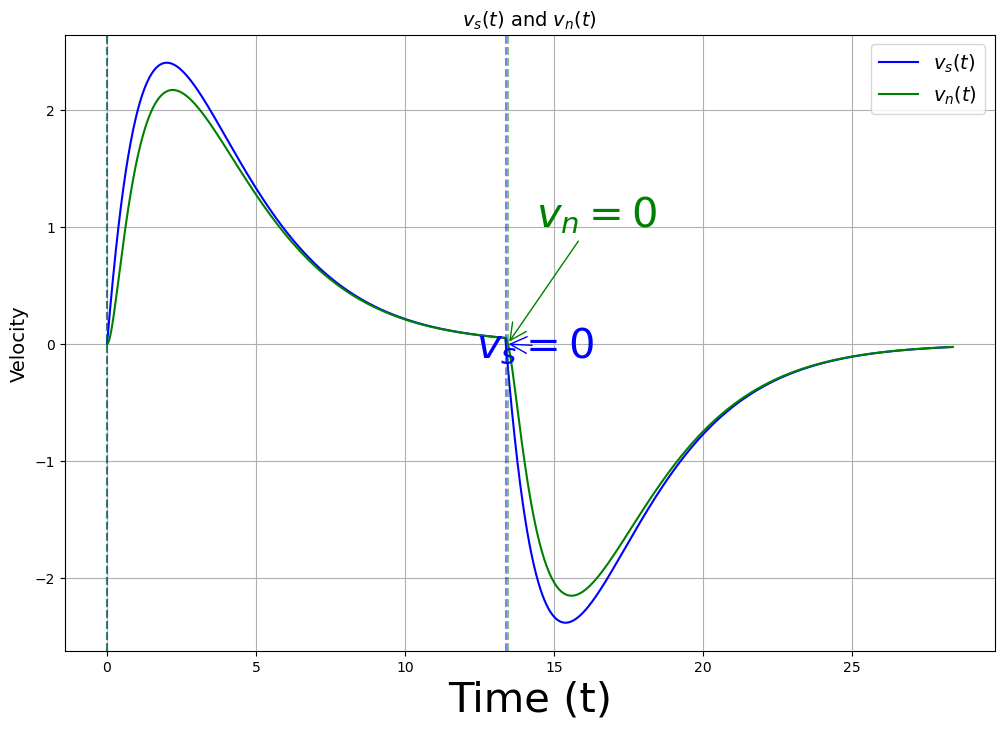

In [30]:
alpha = 6
beta = 0.5
nu = 5
gamma = 0.51
plot_2(alpha,beta,nu,gamma,13.36)

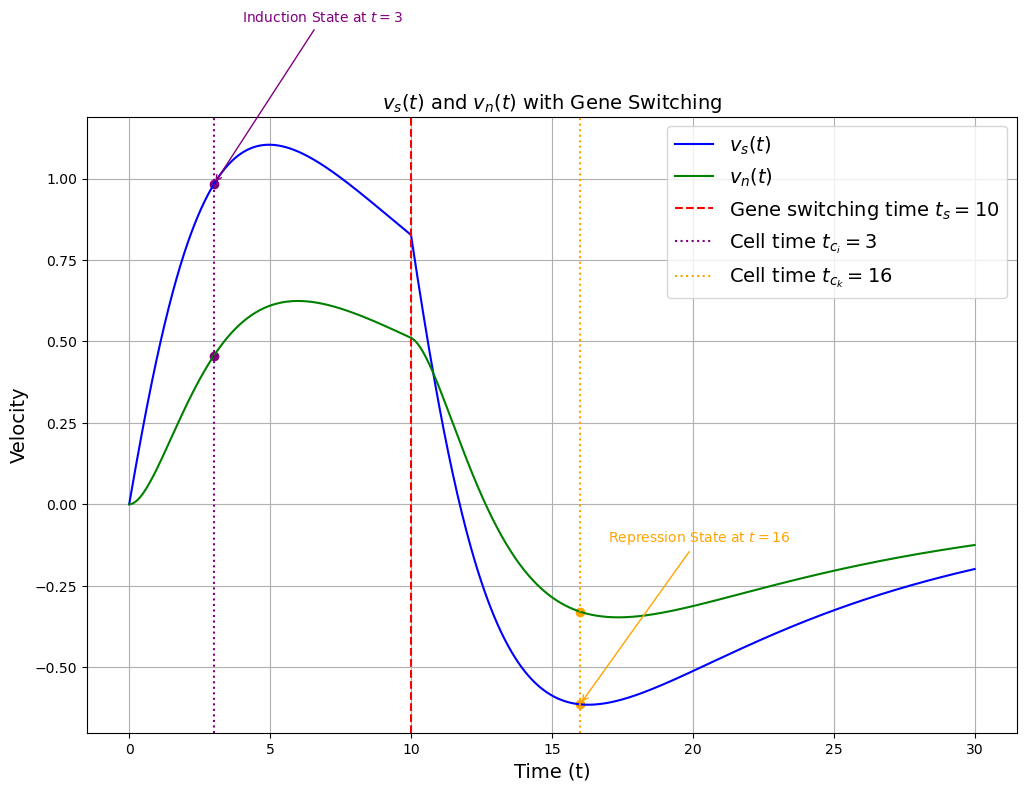

In [87]:
import numpy as np 
import matplotlib.pyplot as plt

# Parameters
alpha = 5
beta = 0.1
nu = 0.68
gamma = 0.5    # Degradation rate of cytoplasmic spliced RNA s_c

# Gene switching time
t_s = 10        # Time when gene switches from induction to repression

# Cell times
t_c_i = 3       # Cell time before switching (induction state)
t_c_k = 16    # Cell time after switching (repression state)

# Time arrays
t_before_switch = np.linspace(0, t_s, 500)         # Time before gene switches
t_after_switch = np.linspace(t_s, t_s + 20, 500)   # Time after gene switches
t_total = np.concatenate((t_before_switch, t_after_switch))

# Functions during induction (alpha > 0)
def u_induction(t):
    return (alpha / beta) * (1 - np.exp(-beta * t))

def s_n_induction(t):
    term1 = (alpha / nu) * (1 - np.exp(-nu * t))
    term2 = (alpha / (nu - beta)) * (np.exp(-nu * t) - np.exp(-beta * t))
    return term1 + term2

def s_c_induction(t):
    term1 = ((alpha / beta) * (1 - np.exp(-beta * t))) / ((nu - beta) * (gamma - beta))
    term2 = ((alpha / nu) * (1 - np.exp(-nu * t))) / ((gamma - nu) * (nu - beta))
    term3 = ((alpha / gamma) * (1 - np.exp(-gamma * t))) / ((gamma - nu) * (gamma - beta))
    return nu * beta * (term1 - term2 + term3)

# Functions during repression (alpha = 0)
# Initial counts at t_s
u_t_s = u_induction(t_s)
s_n_t_s = s_n_induction(t_s)
s_c_t_s = s_c_induction(t_s)

def u_repression(t):
    return u_t_s * np.exp(-beta * (t - t_s))

def s_n_repression(t):
    term1 = s_n_t_s * np.exp(-nu * (t - t_s))
    term2 = (beta * u_t_s) / (nu - beta) * (np.exp(-nu * (t - t_s)) - np.exp(-beta * (t - t_s)))
    return term1 - term2

def s_c_repression(t):
    term1 = (u_t_s * np.exp(-beta * (t - t_s))) / ((nu - beta) * (gamma - beta))
    term2 = (u_t_s * np.exp(-nu * (t - t_s))) / ((gamma - nu) * (nu - beta))
    term3 = (u_t_s * np.exp(-gamma * (t - t_s))) / ((gamma - nu) * (gamma - beta))
    part1 = nu * beta * (term1 - term2 + term3)
    part2 = (nu / (gamma - nu)) * (np.exp(-nu * (t - t_s)) - np.exp(-gamma * (t - t_s))) * s_n_t_s
    part3 = np.exp(-gamma * (t - t_s)) * s_c_t_s
    return part1 + part2 + part3

# Combine functions for the entire time span
u_total = np.concatenate((u_induction(t_before_switch), u_repression(t_after_switch)))
s_n_total = np.concatenate((s_n_induction(t_before_switch), s_n_repression(t_after_switch)))
s_c_total = np.concatenate((s_c_induction(t_before_switch), s_c_repression(t_after_switch)))

# Calculate velocities
v_su_total = beta * u_total - gamma * s_c_total
v_nc_total = nu * s_n_total - gamma * s_c_total

# Plotting the velocities over time
plt.figure(figsize=(12, 8))
plt.plot(t_total, v_su_total, label=r'$v_{s}(t)$', color='blue')
plt.plot(t_total, v_nc_total, label=r'$v_{n}(t)$', color='green')

# Mark gene switching time
plt.axvline(t_s, color='red', linestyle='--', label=rf'Gene switching time $t_s = {t_s}$')

# Mark cell times
plt.axvline(t_c_i, color='purple', linestyle=':', label=rf'Cell time $t_{{c_i}} = {t_c_i}$')
plt.axvline(t_c_k, color='orange', linestyle=':', label=rf'Cell time $t_{{c_k}} = {t_c_k}$')

# Indicate velocities at cell times
v_su_t_c_i = beta * u_induction(t_c_i) - gamma * s_c_induction(t_c_i)
v_nc_t_c_i = nu * s_n_induction(t_c_i) - gamma * s_c_induction(t_c_i)

v_su_t_c_k = beta * u_repression(t_c_k) - gamma * s_c_repression(t_c_k)
v_nc_t_c_k = nu * s_n_repression(t_c_k) - gamma * s_c_repression(t_c_k)

plt.scatter([t_c_i], [v_su_t_c_i], color='purple')
plt.scatter([t_c_i], [v_nc_t_c_i], color='purple')

plt.scatter([t_c_k], [v_su_t_c_k], color='orange')
plt.scatter([t_c_k], [v_nc_t_c_k], color='orange')

# Annotations
plt.annotate(f'Induction State at $t = {t_c_i}$', xy=(t_c_i, v_su_t_c_i), xytext=(t_c_i + 1 , v_su_t_c_i + 0.5),
             arrowprops=dict(arrowstyle='->', color='purple'), color='purple')
plt.annotate(f'Repression State at $t = {t_c_k}$', xy=(t_c_k, v_su_t_c_k), xytext=(t_c_k + 1, v_su_t_c_k + 0.5),
             arrowprops=dict(arrowstyle='->', color='orange'), color='orange')
plt.title('$v_{s}(t)$ and $v_{n}(t)$ with Gene Switching',fontsize=14)
plt.xlabel('Time (t)',fontsize=14)
plt.ylabel('Velocity',fontsize=14)
plt.legend(fontsize=14)
plt.grid(True)
plt.show()


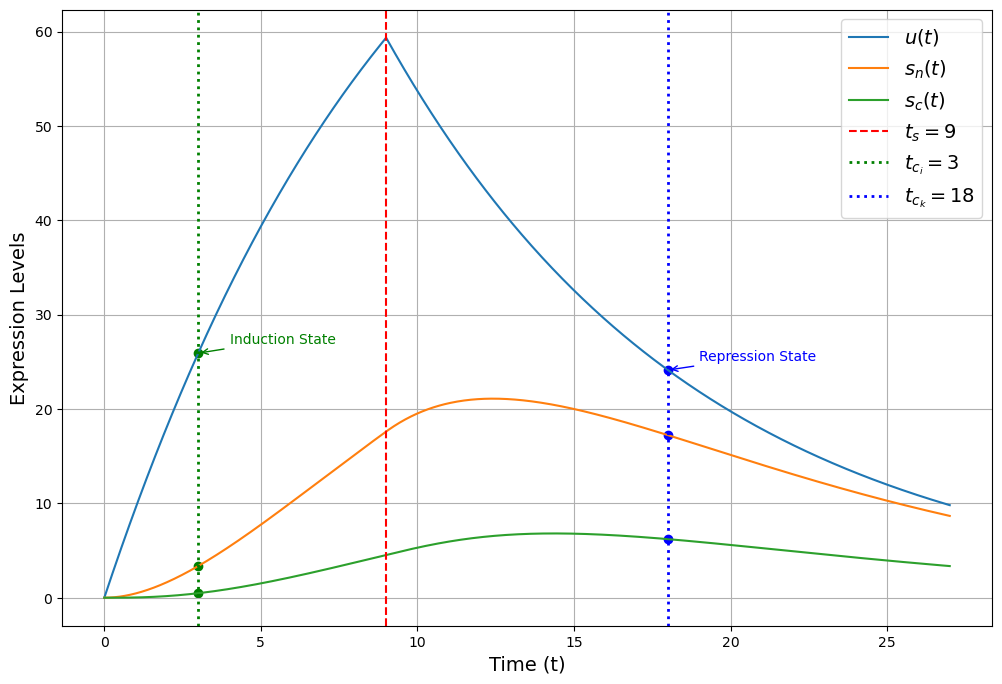

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
# alpha = 6.7
# beta = 1.5
# nu = 1.2
# gamma = 0.1
# [6, 0.5, 0.44, 0.41]
# [6,0.83,0.68,0.7]
alpha = 10
beta = 0.1
nu = 0.2
gamma = 0.6   # Degradation rate of protein s_c

# Gene switching time
t_s = 9       # Time when gene switches from induction to repression

# Cell times
t_c_i = 3          # Cell time before switching (induction state)
t_c_k = 18       # Cell time after switching (repression state)

# Time arrays
t_before_switch = np.linspace(0, t_s, 500)         # Time before gene switches
t_after_switch = np.linspace(t_s, t_s + 18, 500)   # Time after gene switches
t_total = np.concatenate((t_before_switch, t_after_switch))

# Functions during induction (alpha > 0)
def u_induction(t):
    return (alpha / beta) * (1 - np.exp(-beta * t))

def s_n_induction(t):
    term1 = (alpha / nu) * (1 - np.exp(-nu * t))
    term2 = (alpha / (nu - beta)) * (np.exp(-nu * t) - np.exp(-beta * t))
    return term1 + term2

def s_c_induction(t):
    term1 = ((alpha / beta) * (1 - np.exp(-beta * t))) / ((nu - beta) * (gamma - beta))
    term2 = ((alpha / nu) * (1 - np.exp(-nu * t))) / ((gamma - nu) * (nu - beta))
    term3 = ((alpha / gamma) * (1 - np.exp(-gamma * t))) / ((gamma - nu) * (gamma - beta))
    return nu * beta * (term1 - term2 + term3)

# Functions during repression (alpha = 0)
# Initial counts at t_s
u_t_s = u_induction(t_s)
s_n_t_s = s_n_induction(t_s)
s_c_t_s = s_c_induction(t_s)

def u_repression(t):
    return u_t_s * np.exp(-beta * (t - t_s))

def s_n_repression(t):
    term1 = s_n_t_s * np.exp(-nu * (t - t_s))
    term2 = (beta * u_t_s) / (nu - beta) * (np.exp(-nu * (t - t_s)) - np.exp(-beta * (t - t_s)))
    return term1 - term2

def s_c_repression(t):
    term1 = (u_t_s * np.exp(-beta * (t - t_s))) / ((nu - beta) * (gamma - beta))
    term2 = (u_t_s * np.exp(-nu * (t - t_s))) / ((gamma - nu) * (nu - beta))
    term3 = (u_t_s * np.exp(-gamma * (t - t_s))) / ((gamma - nu) * (gamma - beta))
    part1 = nu * beta * (term1 - term2 + term3)
    part2 = (nu / (gamma - nu)) * (np.exp(-nu * (t - t_s)) - np.exp(-gamma * (t - t_s))) * s_n_t_s
    part3 = np.exp(-gamma * (t - t_s)) * s_c_t_s
    return part1 + part2 + part3

# Combine functions for the entire time span
u_total = np.concatenate((u_induction(t_before_switch), u_repression(t_after_switch)))
s_n_total = np.concatenate((s_n_induction(t_before_switch), s_n_repression(t_after_switch)))
s_c_total = np.concatenate((s_c_induction(t_before_switch), s_c_repression(t_after_switch)))

# Plotting
plt.figure(figsize=(12, 8))
plt.plot(t_total, u_total, label=r'$u(t)$')
plt.plot(t_total, s_n_total, label=r'$s_n(t)$')
plt.plot(t_total, s_c_total, label=r'$s_c(t)$')

# Mark gene switching time
plt.axvline(t_s, color='red', linestyle='--', label=rf'$t_s = {t_s}$')

# Mark cell times
plt.axvline(t_c_i, color='green', linestyle=':',linewidth=2, label=rf'$t_{{c_i}} = {t_c_i}$')
plt.axvline(t_c_k, color='blue', linestyle=':',linewidth=2, label=rf'$t_{{c_k}} = {t_c_k}$')

# Indicate gene state at cell times
u_t_c_i = u_induction(t_c_i)
s_n_t_c_i = s_n_induction(t_c_i)
s_c_t_c_i = s_c_induction(t_c_i)

u_t_c_k = u_repression(t_c_k)
s_n_t_c_k = s_n_repression(t_c_k)
s_c_t_c_k = s_c_repression(t_c_k)

plt.scatter([t_c_i], [u_t_c_i], color='green')
plt.scatter([t_c_i], [s_n_t_c_i], color='green')
plt.scatter([t_c_i], [s_c_t_c_i], color='green')

plt.scatter([t_c_k], [u_t_c_k], color='blue')
plt.scatter([t_c_k], [s_n_t_c_k], color='blue')
plt.scatter([t_c_k], [s_c_t_c_k], color='blue')

# Annotations
plt.annotate('Induction State', xy=(t_c_i, u_t_c_i), xytext=(t_c_i + 1, u_t_c_i + 1),
             arrowprops=dict(arrowstyle='->', color='green'), color='green')
plt.annotate('Repression State', xy=(t_c_k, u_t_c_k), xytext=(t_c_k + 1, u_t_c_k + 1),
             arrowprops=dict(arrowstyle='->', color='blue'), color='blue')

plt.title('',fontsize=14)
plt.xlabel('Time (t)',fontsize=14)
plt.ylabel('Expression Levels',fontsize=14)
plt.legend(fontsize=14)
plt.grid(True)  
plt.show()


# cell times 

In [8]:
import numpy as np 
def draw_poisson(n):
    from random import  uniform  # Draw from Poisson 

    t = np.cumsum([-0.1 * np.log(uniform(0, 1)) for _ in range(n - 1)])
    return np.insert(t, 0, 0)  # Prepend t0=0

In [51]:
from random import  uniform
t = np.cumsum([-0.1 * np.log(uniform(0, 1)) for _ in range(12)])

In [49]:
t= [-0.1 * np.log(uniform(0, 1)) for _ in range(12 - 1)]

In [52]:
t

array([0.07777302, 0.27276189, 0.3819613 , 0.38760508, 0.4030529 ,
       0.45889564, 0.47354004, 0.80284981, 0.824942  , 0.9392233 ,
       1.09602077, 1.31122129])

In [25]:
import matplotlib.pyplot as plt

C:\Users\OmerCagatayTalikaci\AppData\Local\Temp\ipykernel_24448\1877367883.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


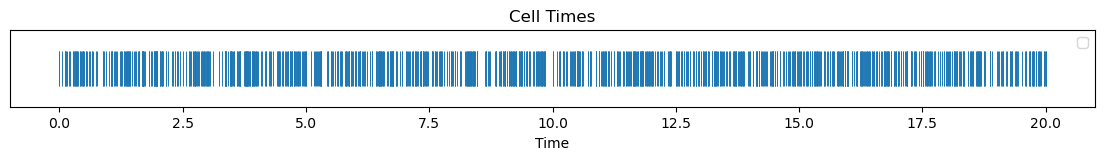

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_obs = 10
t_max = 20
# random_seed = 42

# Simulate cell times

cell_times = draw_poisson(1000)
cell_times = cell_times * t_max / np.max(cell_times)

# Plotting
plt.figure(figsize=(14, 1))
plt.eventplot(cell_times, orientation='horizontal',linewidths=0.7)
# plt.axvline(t_max, color='red', linestyle='--', label='t_max')
plt.title('Cell Times')
plt.xlabel('Time')
plt.yticks([])  # Hide y-axis ticks
plt.legend()
plt.show()
